In [6]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

%pip install mlflow
import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
try:
    from google.colab import files
    print("Select your cleaned Layoffs CSV file.")
    uploaded = files.upload()
    file_name = next(iter(uploaded.keys()))
except ImportError:
    print("Google Colab upload is not available.")
    file_name = input("Enter CSV file path: ").strip()

df = pd.read_csv(file_name)

print("Selected file:", file_name)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())

Select your cleaned Layoffs CSV file.


Saving layoffs_cleaned _final.csv to layoffs_cleaned _final.csv
Selected file: layoffs_cleaned _final.csv
Rows: 5676
Columns: 21


,record_id,company,city,country,is_us,industry,stage,company_size_before,company_size_after,total_laid_off,percentage_laid_off,funds_raised_mil,date,year,date_added,status,quarter,month_name,day_of_week,is_weekend,days_to_report
0,layoff_01916,Kaiyo,NEW YORK CITY,United States,True,Retail,Series B,397,633.0,54.0,100.0,43.0,2024-08-21,2024,2024-08-22,Unknown,3,August,Wednesday,False,1
1,layoff_00360,Trell,Bengaluru,India,False,Retail,Unknown,600,300.0,300.0,50.0,62.0,2022-03-15,2022,2022-05-07,Unknown,1,March,Tuesday,False,53
2,layoff_02462,Flowhub,Dever,unknown,False,Cannabis,Unknown,700,700.0,25.0,15.0,974.0,2022-09-09,2022,2022-09-09,Private,3,September,Friday,False,0
3,layoff_01425,trigo,Tel Aviv,Israel,False,Retail,Series C,200,170.0,30.0,15.0,199.0,2024-01-04,2024,2024-01-05,Unknown,1,January,Thursday,False,1
4,layoff_03829,New Relic,Unknown,United States,True,INFRASTRUCTURE,Post-IPO,2550,30.0,255.0,10.0,173.0,2023-06-27,2023,2023-06-27,Unknown,2,June,Tuesday,False,0


In [8]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
display(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (5676, 21)

Columns:
['record_id', 'company', 'city', 'country', 'is_us', 'industry', 'stage', 'company_size_before', 'company_size_after', 'total_laid_off', 'percentage_laid_off', 'funds_raised_mil', 'date', 'year', 'date_added', 'status', 'quarter', 'month_name', 'day_of_week', 'is_weekend', 'days_to_report']

Missing values:


,0
record_id,0
company,0
city,0
country,0
is_us,0
industry,0
stage,0
company_size_before,0
company_size_after,0
total_laid_off,0



Duplicate rows: 0


Target distribution:


,Records
high_layoff,
0,4887
1,789


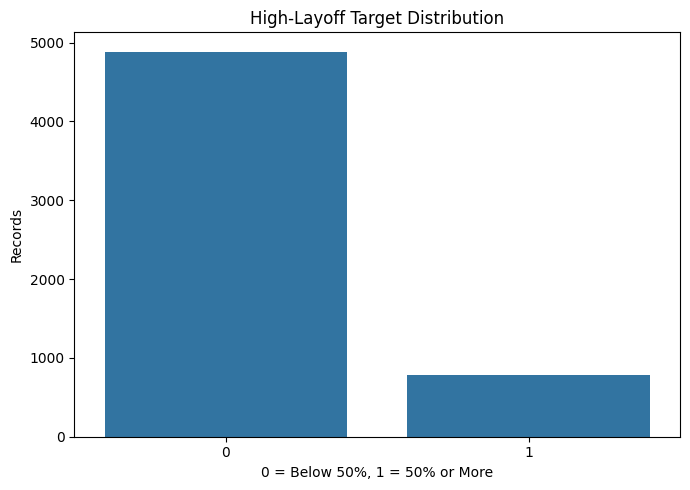

In [9]:
if "percentage_laid_off" not in df.columns:
    raise ValueError("The dataset must contain percentage_laid_off.")

df["high_layoff"] = (df["percentage_laid_off"] >= 50).astype(int)

print("Target distribution:")
display(df["high_layoff"].value_counts().sort_index().to_frame("Records"))

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="high_layoff")
plt.title("High-Layoff Target Distribution")
plt.xlabel("0 = Below 50%, 1 = 50% or More")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

In [10]:
target = "high_layoff"

excluded = [
    "high_layoff",
    "percentage_laid_off",
    "company",
    "date"
]

feature_columns = [c for c in df.columns if c not in excluded]

X = df[feature_columns].copy()
y = df[target].copy()

constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)
    print("Removed constant columns:", constant_cols)

print("Features:", X.columns.tolist())
print("X shape:", X.shape)

Features: ['record_id', 'city', 'country', 'is_us', 'industry', 'stage', 'company_size_before', 'company_size_after', 'total_laid_off', 'funds_raised_mil', 'year', 'date_added', 'status', 'quarter', 'month_name', 'day_of_week', 'is_weekend', 'days_to_report']
X shape: (5676, 18)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 4540
Testing samples : 1136


In [12]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

Numerical: ['company_size_before', 'company_size_after', 'total_laid_off', 'funds_raised_mil', 'year', 'quarter', 'days_to_report']
Categorical: ['record_id', 'city', 'country', 'is_us', 'industry', 'stage', 'date_added', 'status', 'month_name', 'day_of_week', 'is_weekend']


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

baseline_results = []
baseline_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    baseline_pipelines[name] = pipe
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    "Accuracy", ascending=False
).reset_index(drop=True)

display(baseline_results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.869718,0.708333,0.107595,0.186813
1,Logistic Regression,0.861796,0.515152,0.107595,0.178010
2,Random Forest,0.861796,0.666667,0.012658,0.024845
3,K-Nearest Neighbors,0.846831,0.289474,0.069620,0.112245
4,Decision Tree,0.841549,0.385417,0.234177,0.291339


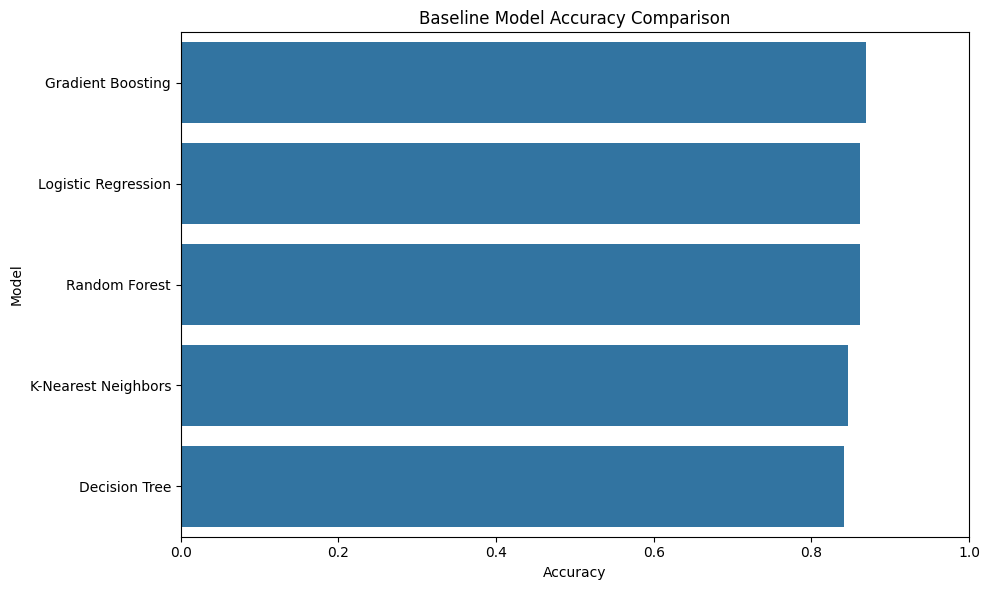

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data=baseline_results_df, x="Accuracy", y="Model")
plt.title("Baseline Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0,1)
plt.tight_layout()
plt.show()

In [15]:
for name, pipe in baseline_pipelines.items():
    pred = pipe.predict(X_test)
    print("="*70)
    print(name)
    print("="*70)
    print(classification_report(
        y_test, pred,
        target_names=["Below 50%", "50% or More"],
        zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

   Below 50%       0.87      0.98      0.92       978
 50% or More       0.52      0.11      0.18       158

    accuracy                           0.86      1136
   macro avg       0.69      0.55      0.55      1136
weighted avg       0.82      0.86      0.82      1136

Decision Tree
              precision    recall  f1-score   support

   Below 50%       0.88      0.94      0.91       978
 50% or More       0.39      0.23      0.29       158

    accuracy                           0.84      1136
   macro avg       0.63      0.59      0.60      1136
weighted avg       0.81      0.84      0.82      1136

Random Forest
              precision    recall  f1-score   support

   Below 50%       0.86      1.00      0.93       978
 50% or More       0.67      0.01      0.02       158

    accuracy                           0.86      1136
   macro avg       0.76      0.51      0.48      1136
weighted avg       0.84   

In [16]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_grid = GridSearchCV(
    rf_pipeline,
    {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Best parameters:", rf_grid.best_params_)
print("Best CV accuracy:", rf_grid.best_score_)
print("Test accuracy:", rf_accuracy)
print("Test precision:", rf_precision)
print("Test recall:", rf_recall)
print("Test F1:", rf_f1)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV accuracy: 0.8621150091253754
Test accuracy: 0.8617957746478874
Test precision: 0.6666666666666666
Test recall: 0.012658227848101266
Test F1: 0.024844720496894408


In [17]:
from sklearn.pipeline import Pipeline

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_grid = GridSearchCV(
    gb_pipeline,
    {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_split": [2, 5]
    },
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

gb_pred = gb_grid.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred, zero_division=0)
gb_recall = recall_score(y_test, gb_pred, zero_division=0)
gb_f1 = f1_score(y_test, gb_pred, zero_division=0)

print("Best parameters:", gb_grid.best_params_)
print("Best CV accuracy:", gb_grid.best_score_)
print("Test accuracy:", gb_accuracy)
print("Test precision:", gb_precision)
print("Test recall:", gb_recall)
print("Test F1:", gb_f1)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_split': 5, 'model__n_estimators': 50}
Best CV accuracy: 0.8625550527455724
Test accuracy: 0.8661971830985915
Test precision: 0.8
Test recall: 0.05063291139240506
Test F1: 0.09523809523809523


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (Baseline),0.861796,0.666667,0.012658,0.024845
1,Random Forest (Tuned),0.861796,0.666667,0.012658,0.024845
2,Gradient Boosting (Baseline),0.869718,0.708333,0.107595,0.186813
3,Gradient Boosting (Tuned),0.866197,0.800000,0.050633,0.095238


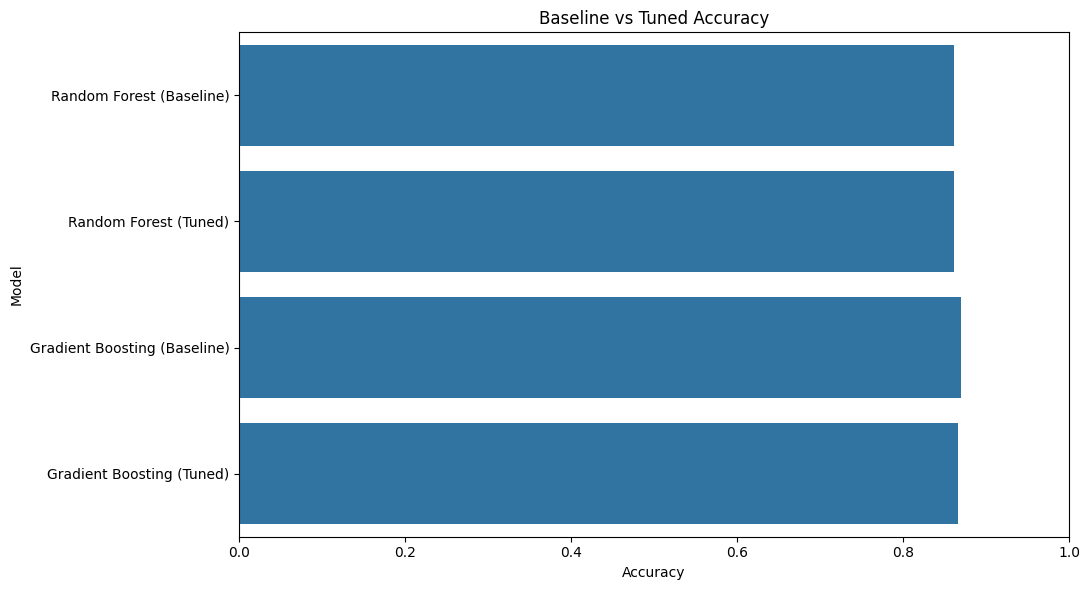

In [18]:
rf_base = baseline_results_df[baseline_results_df["Model"]=="Random Forest"].iloc[0]
gb_base = baseline_results_df[baseline_results_df["Model"]=="Gradient Boosting"].iloc[0]

comparison = pd.DataFrame([
    {"Model":"Random Forest (Baseline)", **rf_base.drop("Model").to_dict()},
    {"Model":"Random Forest (Tuned)", "Accuracy":rf_accuracy, "Precision":rf_precision, "Recall":rf_recall, "F1 Score":rf_f1},
    {"Model":"Gradient Boosting (Baseline)", **gb_base.drop("Model").to_dict()},
    {"Model":"Gradient Boosting (Tuned)", "Accuracy":gb_accuracy, "Precision":gb_precision, "Recall":gb_recall, "F1 Score":gb_f1}
])

display(comparison)

plt.figure(figsize=(11,6))
sns.barplot(data=comparison, x="Accuracy", y="Model")
plt.title("Baseline vs Tuned Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0,1)
plt.tight_layout()
plt.show()

In [19]:
all_results = pd.concat([
    baseline_results_df,
    pd.DataFrame([
        {"Model":"Random Forest (Tuned)", "Accuracy":rf_accuracy, "Precision":rf_precision, "Recall":rf_recall, "F1 Score":rf_f1},
        {"Model":"Gradient Boosting (Tuned)", "Accuracy":gb_accuracy, "Precision":gb_precision, "Recall":gb_recall, "F1 Score":gb_f1}
    ])
], ignore_index=True)

all_results = all_results.sort_values(
    ["Accuracy", "F1 Score"], ascending=False
).reset_index(drop=True)

display(all_results)

model_objects = {
    "Logistic Regression": baseline_pipelines["Logistic Regression"],
    "Decision Tree": baseline_pipelines["Decision Tree"],
    "Random Forest": baseline_pipelines["Random Forest"],
    "Gradient Boosting": baseline_pipelines["Gradient Boosting"],
    "K-Nearest Neighbors": baseline_pipelines["K-Nearest Neighbors"],
    "Random Forest (Tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (Tuned)": gb_grid.best_estimator_
}

best_model_name = all_results.iloc[0]["Model"]
best_model = model_objects[best_model_name]

print("BEST MODEL:", best_model_name)
print("BEST ACCURACY:", all_results.iloc[0]["Accuracy"])

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.869718,0.708333,0.107595,0.186813
1,Gradient Boosting (Tuned),0.866197,0.800000,0.050633,0.095238
2,Logistic Regression,0.861796,0.515152,0.107595,0.178010
3,Random Forest,0.861796,0.666667,0.012658,0.024845
4,Random Forest (Tuned),0.861796,0.666667,0.012658,0.024845
5,K-Nearest Neighbors,0.846831,0.289474,0.069620,0.112245
6,Decision Tree,0.841549,0.385417,0.234177,0.291339


BEST MODEL: Gradient Boosting
BEST ACCURACY: 0.8697183098591549


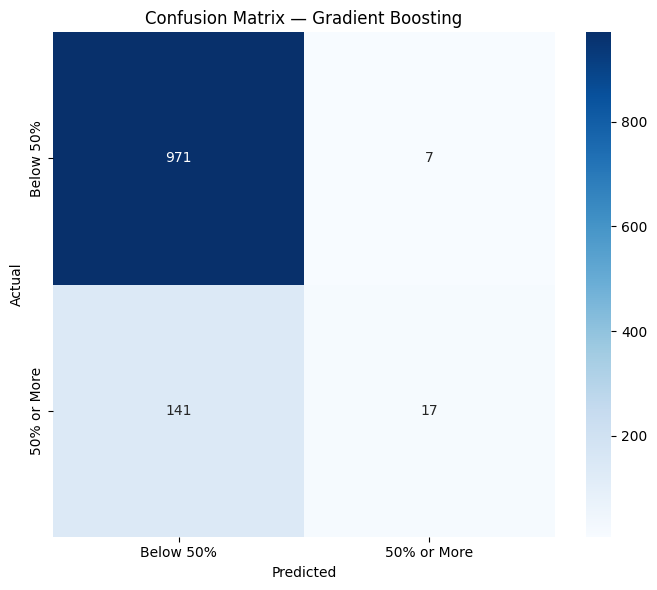

              precision    recall  f1-score   support

   Below 50%       0.87      0.99      0.93       978
 50% or More       0.71      0.11      0.19       158

    accuracy                           0.87      1136
   macro avg       0.79      0.55      0.56      1136
weighted avg       0.85      0.87      0.83      1136



In [20]:
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Below 50%", "50% or More"],
    yticklabels=["Below 50%", "50% or More"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test, best_pred,
    target_names=["Below 50%", "50% or More"],
    zero_division=0
))

In [21]:
!pip install -q -U mlflow

import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Layoffs_Experiment_4")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow experiment configured: Layoffs_Experiment_4")

MLflow tracking URI: sqlite:///mlflow.db
MLflow experiment configured: Layoffs_Experiment_4


In [24]:
for name, pipe in baseline_pipelines.items():

    pred = pipe.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0)
    }

    with mlflow.start_run(run_name=name.replace(" ", "_")):

        mlflow.log_param("model", name)
        mlflow.log_param("task", "binary_classification")
        mlflow.log_param("target", "high_layoff")
        mlflow.log_param("test_size", 0.20)
        mlflow.log_param("random_state", 42)

        for metric_name, value in metrics.items():
            mlflow.log_metric(metric_name, float(value))

        # Log sklearn pipeline with trusted types
        mlflow.sklearn.log_model(
            pipe,
            name="model",
            skops_trusted_types=[
                "numpy.dtype",
                "sklearn.compose._column_transformer._RemainderColsList"
            ]
        )

print("Baseline runs logged successfully.")

Baseline runs logged successfully.


In [26]:
with mlflow.start_run(run_name="Random_Forest_Tuned"):

    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("tuning", "GridSearchCV")
    mlflow.log_param("cv", 3)

    for param, value in rf_grid.best_params_.items():
        mlflow.log_param(
            param.replace("model__", ""),
            str(value)
        )

    mlflow.log_metric(
        "cv_accuracy",
        float(rf_grid.best_score_)
    )

    mlflow.log_metric(
        "test_accuracy",
        float(rf_accuracy)
    )

    mlflow.log_metric(
        "test_precision",
        float(rf_precision)
    )

    mlflow.log_metric(
        "test_recall",
        float(rf_recall)
    )

    mlflow.log_metric(
        "test_f1_score",
        float(rf_f1)
    )

    # Save the tuned pipeline/model
    mlflow.sklearn.log_model(
        rf_grid.best_estimator_,
        name="model",
        skops_trusted_types=[
            "numpy.dtype",
            "sklearn.compose._column_transformer._RemainderColsList"
        ]
    )

print("Tuned Random Forest logged.")

Tuned Random Forest logged.


In [28]:
with mlflow.start_run(run_name="Gradient_Boosting_Tuned"):

    mlflow.log_param("model", "Gradient Boosting")
    mlflow.log_param("tuning", "GridSearchCV")
    mlflow.log_param("cv", 3)

    for param, value in gb_grid.best_params_.items():
        mlflow.log_param(
            param.replace("model__", ""),
            str(value)
        )

    mlflow.log_metric(
        "cv_accuracy",
        float(gb_grid.best_score_)
    )

    mlflow.log_metric(
        "test_accuracy",
        float(gb_accuracy)
    )

    mlflow.log_metric(
        "test_precision",
        float(gb_precision)
    )

    mlflow.log_metric(
        "test_recall",
        float(gb_recall)
    )

    mlflow.log_metric(
        "test_f1_score",
        float(gb_f1)
    )

    # Log the trained Gradient Boosting pipeline
    mlflow.sklearn.log_model(
        gb_grid.best_estimator_,
        name="model",
        skops_trusted_types=[
            "numpy.dtype",
            "sklearn.compose._column_transformer._RemainderColsList"
        ]
    )

print("Tuned Gradient Boosting logged.")

Tuned Gradient Boosting logged.


In [30]:
best_row = all_results.iloc[0]

with mlflow.start_run(run_name="FINAL_BEST_MODEL"):

    mlflow.log_param("selected_model", best_model_name)
    mlflow.log_param("task", "binary_classification")
    mlflow.log_param("target", "high_layoff")
    mlflow.log_param("feature_count", X.shape[1])

    mlflow.log_metric(
        "accuracy",
        float(best_row["Accuracy"])
    )

    mlflow.log_metric(
        "precision",
        float(best_row["Precision"])
    )

    mlflow.log_metric(
        "recall",
        float(best_row["Recall"])
    )

    mlflow.log_metric(
        "f1_score",
        float(best_row["F1 Score"])
    )

    # Log final best model
    mlflow.sklearn.log_model(
        best_model,
        name="model",
        skops_trusted_types=[
            "numpy.dtype",
            "sklearn.compose._column_transformer._RemainderColsList"
        ]
    )

print("Final best model logged to MLflow.")

Final best model logged to MLflow.


In [31]:
model_filename = "best_layoffs_model.pkl"
joblib.dump(best_model, model_filename)

print("Saved:", model_filename)
print("Size:", os.path.getsize(model_filename), "bytes")

Saved: best_layoffs_model.pkl
Size: 210909 bytes


In [32]:
loaded_model = joblib.load(model_filename)
loaded_pred = loaded_model.predict(X_test)
loaded_accuracy = accuracy_score(y_test, loaded_pred)

print("Saved model accuracy:", loaded_accuracy)
print("Original best accuracy:", best_row["Accuracy"])

if np.isclose(loaded_accuracy, best_row["Accuracy"]):
    print("Verification successful.")
else:
    print("Verification warning: metrics differ.")

Saved model accuracy: 0.8697183098591549
Original best accuracy: 0.8697183098591549
Verification successful.


In [33]:
baseline_results_df.to_csv("baseline_model_results.csv", index=False)
comparison.to_csv("baseline_vs_tuned_results.csv", index=False)
all_results.to_csv("all_model_comparison_results.csv", index=False)

print("Saved result files:")
print("- baseline_model_results.csv")
print("- baseline_vs_tuned_results.csv")
print("- all_model_comparison_results.csv")
print("- best_layoffs_model.pkl")

Saved result files:
- baseline_model_results.csv
- baseline_vs_tuned_results.csv
- all_model_comparison_results.csv
- best_layoffs_model.pkl


In [34]:
print("="*75)
print("EXPERIMENT 4 — FINAL RESULTS")
print("="*75)

print("\nModel comparison:")
display(all_results)

print("\nSelected best model:", best_model_name)
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1 Score : {best_row['F1 Score']:.4f}")

print("\nMLflow experiment: Layoffs_Experiment_4")
print("Saved model: best_layoffs_model.pkl")

EXPERIMENT 4 — FINAL RESULTS

Model comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.869718,0.708333,0.107595,0.186813
1,Gradient Boosting (Tuned),0.866197,0.800000,0.050633,0.095238
2,Logistic Regression,0.861796,0.515152,0.107595,0.178010
3,Random Forest,0.861796,0.666667,0.012658,0.024845
4,Random Forest (Tuned),0.861796,0.666667,0.012658,0.024845
5,K-Nearest Neighbors,0.846831,0.289474,0.069620,0.112245
6,Decision Tree,0.841549,0.385417,0.234177,0.291339



Selected best model: Gradient Boosting
Accuracy : 0.8697
Precision: 0.7083
Recall   : 0.1076
F1 Score : 0.1868

MLflow experiment: Layoffs_Experiment_4
Saved model: best_layoffs_model.pkl
